In [ ]:
import requests
import pandas as pd
import time

API_KEY = "..."
BASE_URL = "https://api.kinopoisk.dev/v1.4/movie"
PAGES = 20
LIMIT = 250
MIN_VOTES = 1000

def safe_join_names(items, key="name", limit=None):
    if not items:
        return None
    names = []
    for item in (items[:limit] if limit else items):
        val = item.get(key)
        if val:
            names.append(val)
    return ", ".join(names) if names else None


def normalize_age_rating(age):
    if age is None:
        return None
    return f"{age}+"


def get_person_name(person):
    return (
        person.get("name")
        or person.get("enName")
        or person.get("alternativeName")
    )


def extract_director(persons):
    if not persons:
        return None
    for person in persons:
        prof = str(person.get("enProfession", "")).lower()
        if "director" in prof:
            return get_person_name(person)
    return None


def extract_top_actors(persons, top_n=3):
    if not persons:
        return None
    actors = []
    for person in persons:
        prof = str(person.get("enProfession", "")).lower()
        if "actor" in prof:
            name = get_person_name(person)
            if name:
                actors.append(name)
        if len(actors) == top_n:
            break
    return ", ".join(actors) if actors else None


def extract_budget_value(movie):
    budget = movie.get("budget")
    if isinstance(budget, dict):
        return budget.get("value")
    return None


def parse_movie(movie):
    genres   = movie.get("genres", [])
    countries = movie.get("countries", [])
    persons  = movie.get("persons", [])

    return {
        "film_id":        movie.get("id"),
        "title":          movie.get("name"),
        "original_title": movie.get("alternativeName") or movie.get("enName"),
        "year":           movie.get("year"),
        "duration":       movie.get("movieLength"),
        "genres":         safe_join_names(genres),
        "countries":      safe_join_names(countries),
        "director":       extract_director(persons),
        "actors_top_3":   extract_top_actors(persons, top_n=3),
        "age_rating":     normalize_age_rating(movie.get("ageRating")),
        "rating_kp":      movie.get("rating", {}).get("kp"),
        "rating_count":   movie.get("votes", {}).get("kp"),
        "description":    movie.get("shortDescription") or movie.get("description"),
        "budget":         extract_budget_value(movie),
    }

def load_page(page, limit=250):
    headers = {
        "X-API-KEY": API_KEY
    }

    params = {
        "page":     page,
        "limit":    limit,
        "type":     "movie",
        "votes.kp": f"{MIN_VOTES}-99999999",
    }

    try:
        response = requests.get(
            BASE_URL,
            headers=headers,
            params=params,
            timeout=60
        )

print("Проверяем доступ к API")
test = load_page(page=1, limit=1)

if test is None:
    print("API недоступен")
else:
    print("API доступен\n")

    all_rows    = []
    failed_pages = []

    for page in range(1, PAGES + 1):
        print(f"Загружаем страницу {page}/{PAGES}...")

        data = load_page(page=page, limit=LIMIT)

        if data and "docs" in data:
            docs = data["docs"]
            if not docs:
                print("Фильмы закончились")
                break

            for movie in docs:
                row = parse_movie(movie)
                all_rows.append(row)

            print(f"  Добавлено: {len(docs)}. Всего: {len(all_rows)}")
        else:
            print(f"  Страница {page} не загружена, пропускаем")
            failed_pages.append(page)

        time.sleep(0.5)

    print(f"\nСобрано фильмов: {len(all_rows)}")

    if failed_pages:
        print(f"Не загружены страницы: {failed_pages}")

    df = pd.DataFrame(all_rows)

    print("\nДо очистки:", df.shape)

    df = df.drop_duplicates(subset=["film_id"])

    df = df.dropna(subset=["rating_kp"])

    df = df.dropna(subset=["year", "duration"])

    df = df[(df["duration"] >= 40) & (df["duration"] <= 240)]

    df = df[df["rating_kp"] > 0]

    print("После очистки:", df.shape)

    print("\nПервые строки:")
    print(df.head())

    print("\nПропуски:")
    print(df.isnull().sum())

    print("\nСтатистика по рейтингу:")
    print(df["rating_kp"].describe())

    df.to_csv("kinopoisk_movies.csv", index=False, encoding="utf-8-sig")

'import requests\nimport pandas as pd\nimport time\n\nAPI_KEY = ""\nBASE_URL = "https://api.kinopoisk.dev/v1.4/movie"\nPAGES = 20\nLIMIT = 250\nMIN_VOTES = 1000\n\ndef safe_join_names(items, key="name", limit=None):\n    if not items:\n        return None\n    names = []\n    for item in (items[:limit] if limit else items):\n        val = item.get(key)\n        if val:\n            names.append(val)\n    return ", ".join(names) if names else None\n\n\ndef normalize_age_rating(age):\n    if age is None:\n        return None\n    return f"{age}+"\n\n\ndef get_person_name(person):\n    return (\n        person.get("name")\n        or person.get("enName")\n        or person.get("alternativeName")\n    )\n\n\ndef extract_director(persons):\n    if not persons:\n        return None\n    for person in persons:\n        prof = str(person.get("enProfession", "")).lower()\n        if "director" in prof:\n            return get_person_name(person)\n    return None\n\n\ndef extract_top_actors(pers

In [2]:
import requests

response = requests.get("https://api.kinopoisk.dev", timeout=10)
print(response.status_code)

200


In [3]:
import pandas as pd
df = pd.read_csv("kinopoisk_movies.csv")
df.head()

,film_id,title,original_title,year,duration,genres,countries,director,actors_top_3,age_rating,rating_kp,rating_count,description,budget
0,11140192,Хороший дом,Dom dobry,2025,107.0,драма,Польша,NaN,NaN,NaN,7.017,2417,"Гошка знакомится в интернете с Гжешеком, обаят...",NaN
1,11122387,7 причин влюбиться,Ғашықпын саған,2026,98.0,мелодрама,Казахстан,NaN,NaN,18+,8.868,84358,Музыкант и студентка влюбляются на фоне городс...,NaN
2,11121442,Абай бол,Абай бол,2025,79.0,комедия,Казахстан,NaN,NaN,16+,7.905,39433,Аферист должен за 24 часа попросить прощения у...,NaN
3,11099137,Мой дед,Мой дед,2025,108.0,приключения,Россия,NaN,NaN,12+,7.791,12413,Дедушка и внук ищут в тайге упавший метеорит. ...,NaN
4,10968587,Вердикт,Keadilan,2025,100.0,"боевик, триллер, драма, криминал, детектив","Индонезия, Корея Южная",NaN,NaN,18+,7.101,37414,Отчаявшийся вдовец захватывает заложников во в...,NaN


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2267 entries, 0 to 2266
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   film_id         2267 non-null   int64  
 1   title           2265 non-null   str    
 2   original_title  2267 non-null   str    
 3   year            2267 non-null   int64  
 4   duration        2267 non-null   float64
 5   genres          2266 non-null   str    
 6   countries       2264 non-null   str    
 7   director        0 non-null      float64
 8   actors_top_3    0 non-null      float64
 9   age_rating      1861 non-null   str    
 10  rating_kp       2267 non-null   float64
 11  rating_count    2267 non-null   int64  
 12  description     2255 non-null   str    
 13  budget          0 non-null      float64
dtypes: float64(5), int64(3), str(6)
memory usage: 248.1 KB


In [12]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from scipy.sparse import hstack, csr_matrix

df = pd.read_csv("kinopoisk_movies.csv")

df = df.drop(columns=["director", "actors_top_3", "budget"], errors="ignore")

df["age_rating"] = df["age_rating"].fillna("unknown")
df["genres"] = df["genres"].fillna("unknown")
df["countries"] = df["countries"].fillna("unknown")

df["description"] = df["description"].fillna("")
df["title"] = df["title"].fillna("")
df["original_title"] = df["original_title"].fillna("")

df["num_genres"] = df["genres"].apply(lambda x: len(str(x).split(", ")))
df["num_countries"] = df["countries"].apply(lambda x: len(str(x).split(", ")))
df["rating_count"] = df["rating_count"].fillna(0)
df["rating_count_log"] = np.log1p(df["rating_count"])

y = df["rating_kp"].values

num_cols = ["year", "duration", "num_genres", "num_countries", "rating_count_log"]
num_features = df[num_cols].values.astype(float)

scaler = StandardScaler(with_mean=False) 
num_features_scaled = scaler.fit_transform(num_features)

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
age_features = ohe.fit_transform(df[["age_rating"]])

genre_vec = CountVectorizer(tokenizer=lambda x: str(x).split(", "), token_pattern=None)
genre_features = genre_vec.fit_transform(df["genres"])

country_vec = CountVectorizer(tokenizer=lambda x: str(x).split(", "), token_pattern=None)
country_features = country_vec.fit_transform(df["countries"])

desc_vec = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_features=30000,     
    sublinear_tf=True,
    token_pattern=r"(?u)\b\w\w+\b"
)
desc_features = desc_vec.fit_transform(df["description"])

title_vec = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_features=20000,
    sublinear_tf=True,
    token_pattern=r"(?u)\b\w\w+\b"
)
title_features = title_vec.fit_transform((df["title"] + " " + df["original_title"]).astype(str))

X = hstack([
    csr_matrix(num_features_scaled),
    age_features,
    genre_features,
    country_features,
    desc_features,
    title_features
]).tocsr()

print("X:", X.shape, "y:", y.shape)

idx = np.arange(len(df))
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, idx, test_size=0.2, random_state=42
)

baseline_pred = np.full_like(y_test, y_train.mean(), dtype=float)
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
print(f"Baseline MAE: {baseline_mae:.4f}")
print(f"Baseline RMSE: {baseline_rmse:.4f}")

ridge = Ridge(random_state=42)

param_grid = {"alpha": np.logspace(-3, 3, 25)}
gs = GridSearchCV(
    ridge,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1
)
gs.fit(X_train, y_train)

best_ridge = gs.best_estimator_
pred = best_ridge.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("\nRidge (tuned)")
print("Best alpha:", gs.best_params_["alpha"])
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

errors_df = df.loc[idx_test, ["title", "rating_kp"]].copy()
errors_df["pred_rating"] = pred
errors_df["error"] = np.abs(errors_df["rating_kp"].values - pred)
errors_df = errors_df.sort_values("error", ascending=False)

print("\nТОП-10 худших предсказаний")
print(errors_df.head(10).to_string(index=False))

print("\nТОП-10 лучших предсказаний")
print(errors_df.tail(10).to_string(index=False))

X: (2267, 10428) y: (2267,)
Baseline MAE: 0.7448
Baseline RMSE: 0.9569

Ridge (tuned)
Best alpha: 5.623413251903491
MAE:  0.4578
RMSE: 0.6098

ТОП-10 худших предсказаний
                       title  rating_kp  pred_rating    error
           Непристойное кино      2.800     6.013045 3.213045
       Непосредственно Каха!      4.625     7.185566 2.560566
        Роналду против Месси      6.279     8.466909 2.187909
      Дети кукурузы: Генезис      3.254     5.068203 1.814203
На пьедестале народной любви      8.771     7.112209 1.658791
 Дилан Моран: Типа, обо всем      8.176     6.563228 1.612772
   Белоснежка и принц эльфов      4.073     5.676141 1.603141
     Клуб анонимных киллеров      4.267     5.849602 1.582602
               Бичи в Майами      5.205     6.777431 1.572431
            Мёртвые ласточки      6.794     5.221609 1.572391

ТОП-10 лучших предсказаний
                     title  rating_kp  pred_rating    error
        Невозможная любовь      6.641     6.666452 0.025452


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

from catboost import CatBoostRegressor, Pool

df = pd.read_csv("kinopoisk_movies.csv")
df = df.drop(columns=["director", "actors_top_3", "budget"], errors="ignore")

df["age_rating"] = df["age_rating"].fillna("unknown")
df["genres"] = df["genres"].fillna("unknown")
df["countries"] = df["countries"].fillna("unknown")

df["description"] = df["description"].fillna("")
df["title"] = df["title"].fillna("")
df["original_title"] = df["original_title"].fillna("")

df["num_genres"] = df["genres"].apply(lambda x: len(str(x).split(", ")))
df["num_countries"] = df["countries"].apply(lambda x: len(str(x).split(", ")))
df["rating_count"] = df["rating_count"].fillna(0)
df["rating_count_log"] = np.log1p(df["rating_count"])

y = df["rating_kp"].values

num_cols  = ["year", "duration", "num_genres", "num_countries", "rating_count_log"]
cat_cols  = ["age_rating"]
text_cols = ["description", "title", "original_title", "genres", "countries"]

feature_cols = num_cols + cat_cols + text_cols
X = df[feature_cols].copy()

idx = np.arange(len(df))
idx_tmp, idx_test = train_test_split(idx, test_size=0.2, random_state=42)
idx_train, idx_valid = train_test_split(idx_tmp, test_size=0.2, random_state=42)  # valid ~16% от всех

X_train, y_train = X.iloc[idx_train], y[idx_train]
X_valid, y_valid = X.iloc[idx_valid], y[idx_valid]
X_test,  y_test  = X.iloc[idx_test],  y[idx_test]

train_pool = Pool(X_train, y_train, cat_features=cat_cols, text_features=text_cols)
valid_pool = Pool(X_valid, y_valid, cat_features=cat_cols, text_features=text_cols)
test_pool  = Pool(X_test,  y_test,  cat_features=cat_cols, text_features=text_cols)

cb = CatBoostRegressor(
    loss_function="MAE",
    eval_metric="MAE",
    iterations=2000,
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=6,
    random_seed=42,
    od_type="Iter",
    od_wait=250,
    verbose=200,
    allow_writing_files=False
)

cb.fit(train_pool, eval_set=valid_pool, use_best_model=True)

pred_cb = cb.predict(test_pool)
mae_cb = mean_absolute_error(y_test, pred_cb)
rmse_cb = np.sqrt(mean_squared_error(y_test, pred_cb))

print("CatBoost")
print(f"MAE:  {mae_cb:.4f}")
print(f"RMSE: {rmse_cb:.4f}")

0:	learn: 0.7668910	test: 0.7925095	best: 0.7925095 (0)	total: 421ms	remaining: 14m 1s
200:	learn: 0.3890628	test: 0.5066117	best: 0.5066117 (200)	total: 51.1s	remaining: 7m 37s
400:	learn: 0.2943223	test: 0.4918662	best: 0.4918662 (400)	total: 1m 37s	remaining: 6m 27s
600:	learn: 0.2482774	test: 0.4865605	best: 0.4864316 (595)	total: 2m 22s	remaining: 5m 32s
800:	learn: 0.2232766	test: 0.4885267	best: 0.4856003 (619)	total: 3m 8s	remaining: 4m 42s
Stopped by overfitting detector  (250 iterations wait)

bestTest = 0.4856002693
bestIteration = 619

Shrink model to first 620 iterations.

CatBoost
MAE:  0.4603
RMSE: 0.6163


In [7]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestRegressor
from scipy.sparse import hstack, csr_matrix

df2 = df.copy()

num_cols = ["year", "duration", "num_genres", "num_countries", "rating_count_log"]
num_features = df2[num_cols].values.astype(float)
scaler = StandardScaler(with_mean=False)
num_features_scaled = scaler.fit_transform(num_features)

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
age_features = ohe.fit_transform(df2[["age_rating"]])

genre_vec = CountVectorizer(tokenizer=lambda x: str(x).split(", "), token_pattern=None)
genre_features = genre_vec.fit_transform(df2["genres"])

country_vec = CountVectorizer(tokenizer=lambda x: str(x).split(", "), token_pattern=None)
country_features = country_vec.fit_transform(df2["countries"])

desc_vec = TfidfVectorizer(
    lowercase=True, ngram_range=(1, 2), min_df=2, max_features=30000,
    sublinear_tf=True, token_pattern=r"(?u)\b\w\w+\b"
)
desc_features = desc_vec.fit_transform(df2["description"])

title_vec = TfidfVectorizer(
    lowercase=True, ngram_range=(1, 2), min_df=2, max_features=20000,
    sublinear_tf=True, token_pattern=r"(?u)\b\w\w+\b"
)
title_features = title_vec.fit_transform((df2["title"] + " " + df2["original_title"]).astype(str))

X_sparse = hstack([
    csr_matrix(num_features_scaled),
    age_features,
    genre_features,
    country_features,
    desc_features,
    title_features
]).tocsr()

Xtr = X_sparse[idx_train]
Xva = X_sparse[idx_valid]
Xte = X_sparse[idx_test]

svd = TruncatedSVD(n_components=300, random_state=42)
Xtr_svd = svd.fit_transform(Xtr)
Xva_svd = svd.transform(Xva)
Xte_svd = svd.transform(Xte)

rf = RandomForestRegressor(
    n_estimators=800,
    max_depth=None,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)
rf.fit(Xtr_svd, y[idx_train])

pred_rf = rf.predict(Xte_svd)
mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))

print("\nRandomForest (TFIDF+SVD)")
print(f"MAE:  {mae_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")


RandomForest (TFIDF+SVD)
MAE:  0.5683
RMSE: 0.7384


In [8]:
pred_ens = 0.5 * pred_cb + 0.5 * pred_rf
mae_ens = mean_absolute_error(y_test, pred_ens)
rmse_ens = np.sqrt(mean_squared_error(y_test, pred_ens))

print("\nEnsemble (0.5 CatBoost + 0.5 RF)")
print(f"MAE:  {mae_ens:.4f}")
print(f"RMSE: {rmse_ens:.4f}")

print("\nCуммарный (MAE)")
print(f"CatBoost:  {mae_cb:.4f}")
print(f"RF:        {mae_rf:.4f}")
print(f"Ensemble:  {mae_ens:.4f}")


Ensemble (0.5 CatBoost + 0.5 RF)
MAE:  0.4935
RMSE: 0.6529

Cуммарный (MAE)
CatBoost:  0.4603
RF:        0.5683
Ensemble:  0.4935


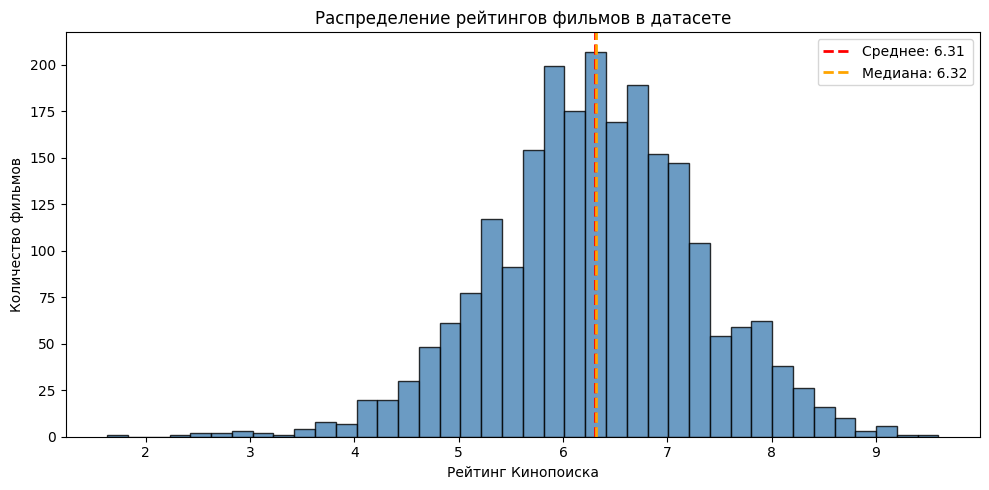

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

plt.figure(figsize=(10, 5))
plt.hist(df["rating_kp"], bins=40, color="steelblue", edgecolor="black", alpha=0.8)
plt.axvline(df["rating_kp"].mean(), color="red", linestyle="--", 
            linewidth=2, label=f"Среднее: {df['rating_kp'].mean():.2f}")
plt.axvline(df["rating_kp"].median(), color="orange", linestyle="--", 
            linewidth=2, label=f"Медиана: {df['rating_kp'].median():.2f}")
plt.xlabel("Рейтинг Кинопоиска")
plt.ylabel("Количество фильмов")
plt.title("Распределение рейтингов фильмов в датасете")
plt.legend()
plt.tight_layout()
plt.show()

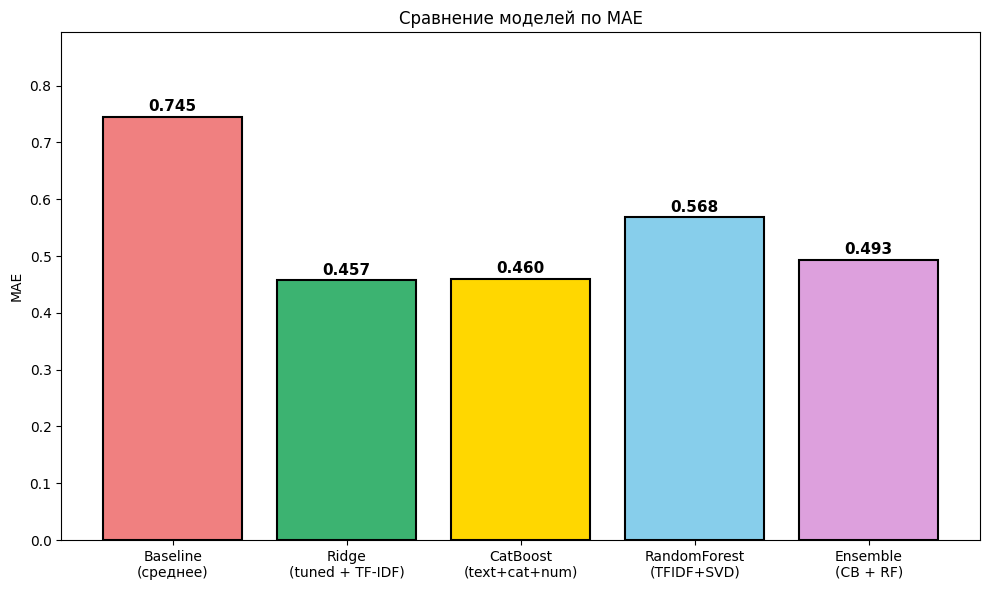

In [10]:
import matplotlib.pyplot as plt

models = [
    "Baseline\n(среднее)",
    "Ridge\n(tuned + TF-IDF)",
    "CatBoost\n(text+cat+num)",
    "RandomForest\n(TFIDF+SVD)",
    "Ensemble\n(CB + RF)",
]

mae_values = [
    baseline_mae,    
    0.4573,           
    0.4603,         
    0.5683,           
    0.4935,           
]

colors = [
    "lightcoral",
    "mediumseagreen",
    "gold",
    "skyblue",
    "plum",
]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, mae_values, color=colors, edgecolor="black", linewidth=1.5)

for bar, val in zip(bars, mae_values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"{val:.3f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.ylabel("MAE")
plt.title("Сравнение моделей по MAE")
plt.ylim(0, max(mae_values) * 1.2)
plt.tight_layout()
plt.show()

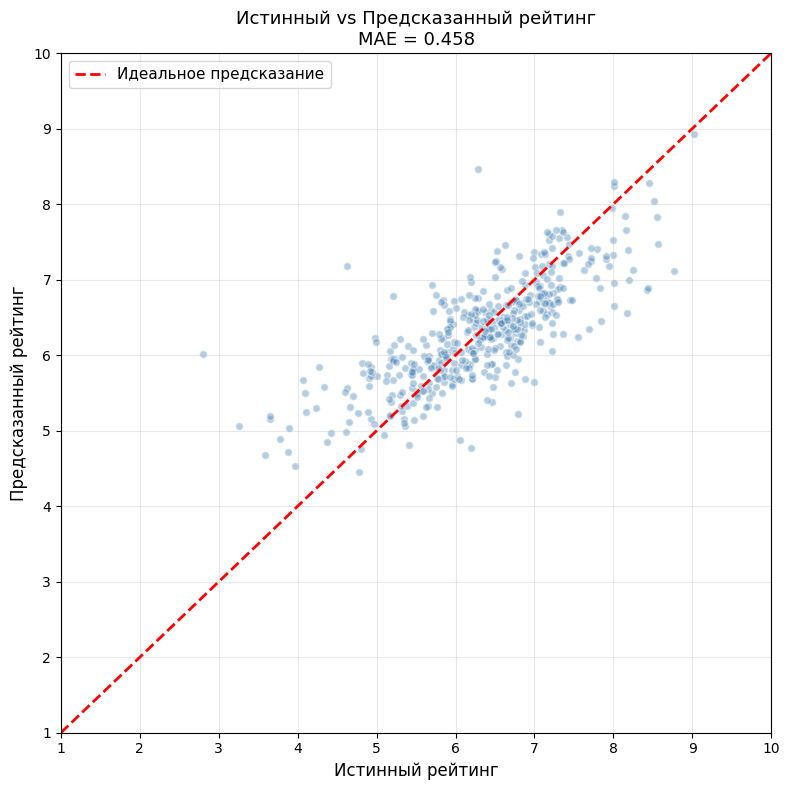

In [14]:
import matplotlib.pyplot as plt

mae_ridge = mean_absolute_error(y_test, pred)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, pred, alpha=0.4, s=30, color="steelblue", edgecolor="white")
plt.plot([1, 10], [1, 10], "r--", linewidth=2, label="Идеальное предсказание")

plt.xlabel("Истинный рейтинг", fontsize=12)
plt.ylabel("Предсказанный рейтинг", fontsize=12)
plt.title(f"Истинный vs Предсказанный рейтинг\nMAE = {mae_ridge:.3f}", fontsize=13)
plt.legend(fontsize=11)
plt.xlim(1, 10)
plt.ylim(1, 10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

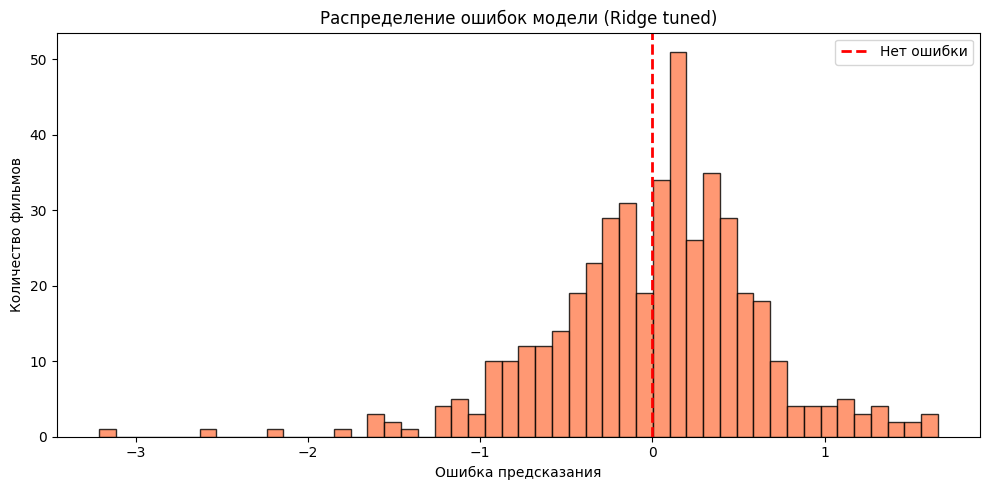

In [20]:
import matplotlib.pyplot as plt
import numpy as np

errors = y_test - pred

plt.figure(figsize=(10, 5))
plt.hist(errors, bins=50, color="coral", edgecolor="black", alpha=0.8)

plt.axvline(0, color="red", linestyle="--", linewidth=2, label="Нет ошибки")

plt.xlabel("Ошибка предсказания")
plt.ylabel("Количество фильмов")
plt.title("Распределение ошибок модели (Ridge tuned)")
plt.legend()
plt.tight_layout()
plt.show()

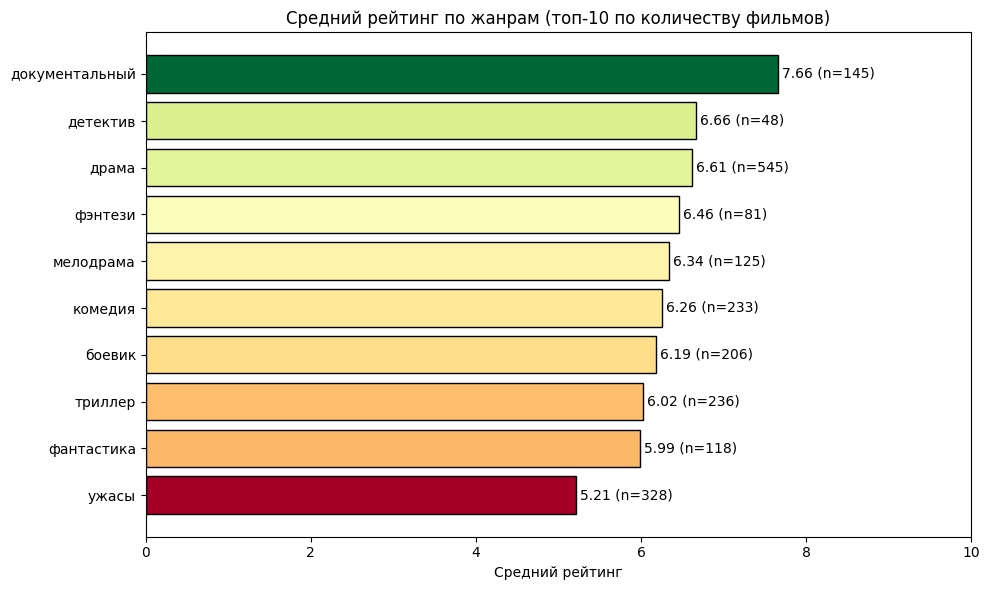

In [16]:
import matplotlib.pyplot as plt
import numpy as np

df["main_genre"] = df["genres"].apply(lambda x: str(x).split(", ")[0] if pd.notna(x) else "unknown")

top_genres = df["main_genre"].value_counts().head(10).index
genre_stats = df[df["main_genre"].isin(top_genres)].groupby("main_genre")["rating_kp"].agg(["mean", "count"])
genre_stats = genre_stats.sort_values("mean", ascending=True)

norm = (genre_stats["mean"] - genre_stats["mean"].min()) / (genre_stats["mean"].max() - genre_stats["mean"].min() + 1e-9)
colors = plt.cm.RdYlGn(norm.values)

plt.figure(figsize=(10, 6))
bars = plt.barh(genre_stats.index, genre_stats["mean"], color=colors, edgecolor="black")

for i, (mean, count) in enumerate(zip(genre_stats["mean"], genre_stats["count"])):
    plt.text(mean + 0.05, i, f"{mean:.2f} (n={count})", va="center", fontsize=10)

plt.xlabel("Средний рейтинг")
plt.title("Средний рейтинг по жанрам (топ-10 по количеству фильмов)")
plt.xlim(0, 10)
plt.tight_layout()
plt.show()

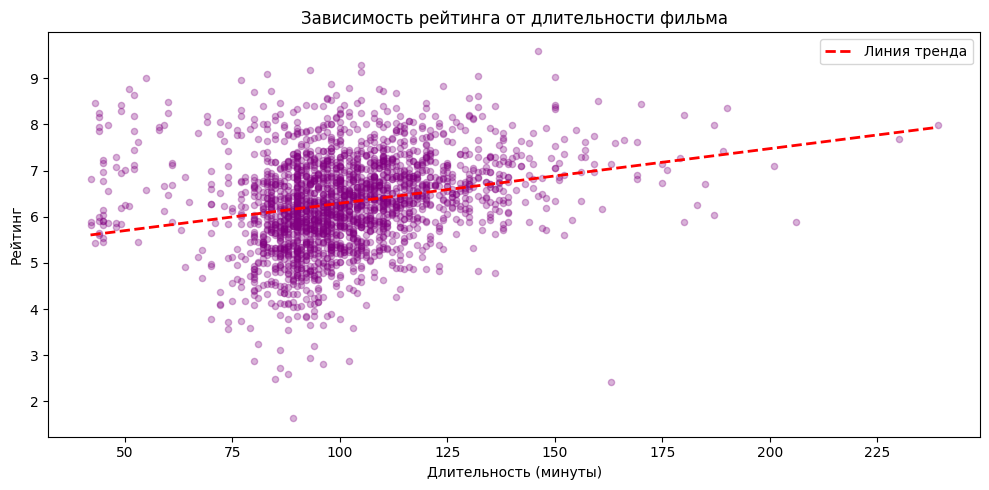

In [17]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 5))
plt.scatter(df["duration"], df["rating_kp"], alpha=0.3, s=20, color="purple")

z = np.polyfit(df["duration"], df["rating_kp"], 1)
p = np.poly1d(z)

duration_range = np.linspace(df["duration"].min(), df["duration"].max(), 100)
plt.plot(duration_range, p(duration_range), "r--", linewidth=2, label="Линия тренда")

plt.xlabel("Длительность (минуты)")
plt.ylabel("Рейтинг")
plt.title("Зависимость рейтинга от длительности фильма")
plt.legend()
plt.tight_layout()
plt.show()

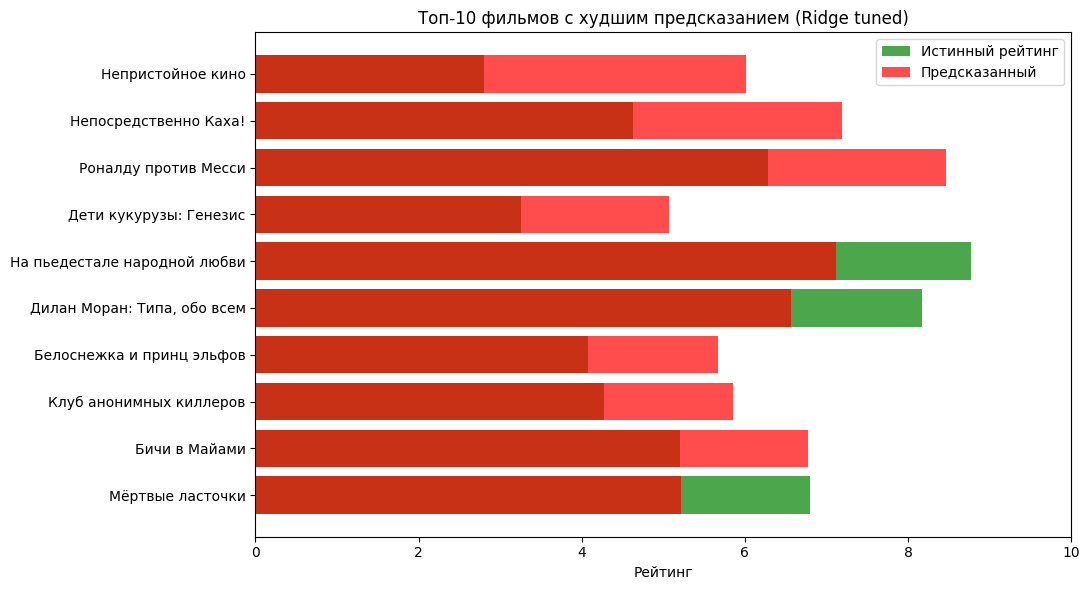

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

errors_df = df.loc[idx_test, ["title", "rating_kp"]].copy()
errors_df["pred_rating"] = pred
errors_df["error"] = np.abs(errors_df["rating_kp"].values - pred)
errors_df = errors_df.sort_values("error", ascending=False)

worst = errors_df.head(10).iloc[::-1]

fig, ax = plt.subplots(figsize=(11, 6))
y_pos = np.arange(len(worst))

ax.barh(y_pos, worst["rating_kp"], alpha=0.7, color="green", label="Истинный рейтинг")
ax.barh(y_pos, worst["pred_rating"], alpha=0.7, color="red", label="Предсказанный")

ax.set_yticks(y_pos)
ax.set_yticklabels(worst["title"])
ax.set_xlabel("Рейтинг")
ax.set_title("Топ-10 фильмов с худшим предсказанием (Ridge tuned)")
ax.legend()
ax.set_xlim(0, 10)

plt.tight_layout()
plt.show()

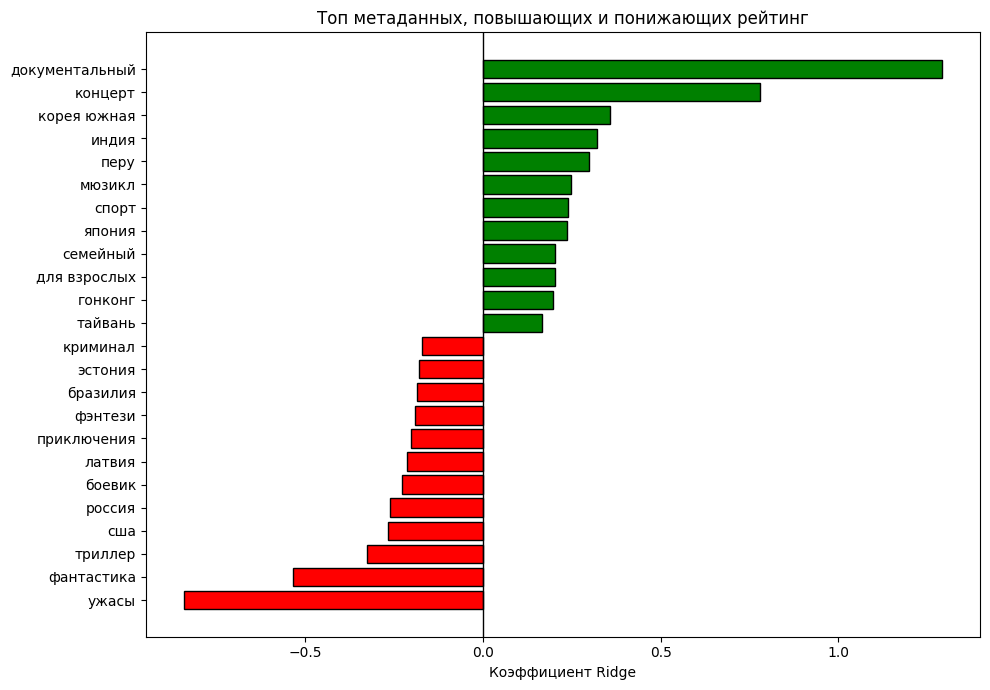

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

age_names = list(ohe.get_feature_names_out(["age_rating"]))
genre_names = list(genre_vec.get_feature_names_out())
country_names = list(country_vec.get_feature_names_out())

n_num = len(num_cols)
n_age = len(age_names)
n_gen = len(genre_names)
n_cnt = len(country_names)

meta_feature_names = (
    num_cols +
    age_names +
    genre_names +
    country_names
)

meta_coefs = best_ridge.coef_[: n_num + n_age + n_gen + n_cnt]

coef_df = pd.DataFrame({"feature": meta_feature_names, "coef": meta_coefs})

coef_df["feature"] = (coef_df["feature"]
                      .str.replace("age_rating_", "age_rating: ", regex=False))

coef_df = coef_df[coef_df["feature"] != "rating_count_log"]
coef_df = coef_df[~coef_df["feature"].str.startswith("age_rating:", na=False)]

top_k = 12
top_pos = coef_df.nlargest(top_k, "coef")
top_neg = coef_df.nsmallest(top_k, "coef")
top_meta = pd.concat([top_neg, top_pos]).sort_values("coef")

plt.figure(figsize=(10, 7))
colors = ["red" if c < 0 else "green" for c in top_meta["coef"]]
plt.barh(top_meta["feature"], top_meta["coef"], color=colors, edgecolor="black", linewidth=1.0)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Коэффициент Ridge")
plt.title("Топ метаданных, повышающих и понижающих рейтинг")
plt.tight_layout()
plt.show()